In [18]:
import geopandas as gpd
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

In [19]:
DATA = Path("../data")

COUNTY_FEATURES = DATA / "processed/counties_al_ms_black_belt_features.geojson"

ELECTIONS = DATA / "raw/elections/countypres_2000-2024.csv"

OUT = DATA / "processed/al_ms_black_belt_elections.geojson"

In [20]:
counties = gpd.read_file(COUNTY_FEATURES)

elections = pd.read_csv(ELECTIONS)

print(counties.shape)
print(elections.shape)

(149, 10)
(94151, 12)


In [21]:
elections = elections[
    (elections["state_po"].isin(["AL", "MS"])) &
    (elections["office"] == "US PRESIDENT") &
    (elections["year"] == 2020)
].copy()

In [22]:
elections = elections[
    elections["party"].isin(["DEMOCRAT", "REPUBLICAN"])
].copy()

In [23]:
votes = elections.pivot_table(
    index="county_fips",
    columns="party",
    values="candidatevotes",
    aggfunc="sum"
).reset_index()

votes.columns.name = None
votes = votes.rename(columns={
    "DEMOCRAT": "dem_votes",
    "REPUBLICAN": "rep_votes"
})

votes.head()

,county_fips,dem_votes,rep_votes
0,1001.0,7503.0,19838.0
1,1003.0,24578.0,83544.0
2,1005.0,4816.0,5622.0
3,1007.0,1986.0,7525.0
4,1009.0,2640.0,24711.0


In [24]:
votes["total_votes"] = votes["dem_votes"] + votes["rep_votes"]

votes["dem_share"] = votes["dem_votes"] / votes["total_votes"]
votes["rep_share"] = votes["rep_votes"] / votes["total_votes"]

In [25]:
votes["county_fips"] = votes["county_fips"].astype(int).astype(str).str.zfill(5)

In [26]:
df = counties.merge(
    votes,
    left_on="GEOID",
    right_on="county_fips",
    how="left"
)

In [27]:
print(df.shape)

df[[
    "NAME",
    "dem_share",
    "rep_share",
    "dist_to_black_belt_km"
]].head()

(149, 16)


,NAME,dem_share,rep_share,dist_to_black_belt_km
0,Cullman,0.108274,0.891726,150.007508
1,Franklin,0.167389,0.832611,59.493919
2,Choctaw,0.421258,0.578742,53.228702
3,Pike,0.412049,0.587951,9.467288
4,Pontotoc,0.184552,0.815448,2.409653


In [28]:
df.to_file(
    OUT,
    driver="GeoJSON"
)

In [29]:
df.drop(columns="geometry").to_csv(
    DATA / "processed/al_ms_black_belt_elections.csv",
    index=False
)

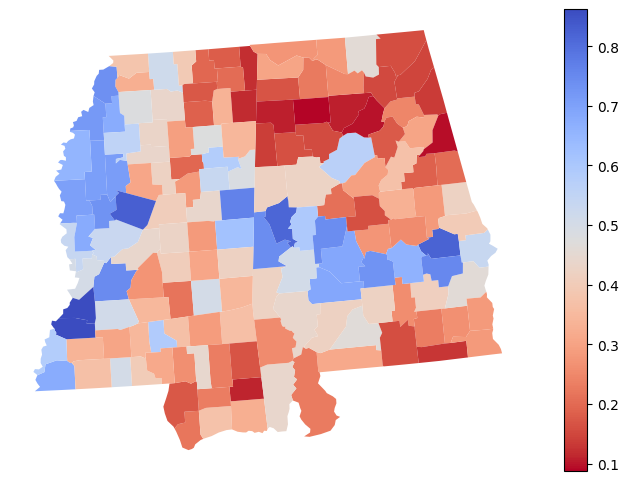

In [30]:
fig, ax = plt.subplots(figsize=(10,6))

df.plot(
    ax=ax,
    column="dem_share",
    cmap="coolwarm_r",
    legend=True,
)

ax.set_axis_off()


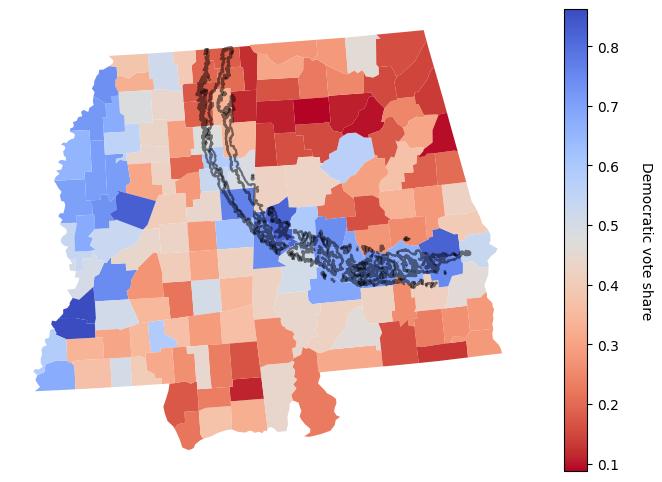

In [31]:
black_belt = gpd.read_file(
    DATA / "processed/black_belt_al_ms_dissolved.geojson"
).to_crs(df.crs)

fig, ax = plt.subplots(figsize=(10,6))

df.plot(
    ax=ax,
    column="dem_share",
    cmap="coolwarm_r",
    legend=True
)

black_belt.boundary.plot(
    ax=ax,
    color="black",
    linewidth=1.5,
    alpha=0.5
)
cbar = next(
    (coll.colorbar for coll in ax.collections if getattr(coll, "colorbar", None) is not None),
    None,
)

if cbar is not None:
    cbar.set_label("Democratic vote share", rotation=270, labelpad=14, va="bottom")
elif len(fig.axes) > 1:
    fig.axes[-1].set_ylabel("Democratic vote share", rotation=270, labelpad=14, va="bottom")

ax.set_axis_off()

plt.savefig("../data/processed/dem_vote_share_map.png", dpi=300, bbox_inches="tight")

In [32]:
import geopandas as gpd
import matplotlib.pyplot as plt
from pathlib import Path

COMMON_CRS = "EPSG:5070"

BLACK_BELT = Path("../data/processed/black_belt_al_ms_dissolved.geojson")
COUNTY_FEATURES = Path("../data/processed/counties_al_ms_black_belt_features.geojson")

MAP_BOUNDARY = Path("../data/raw/geology/usgs_mississippi_alluvial_plain/Mississippi_Alluvial_Plain.shp")

In [33]:
black_belt = gpd.read_file(BLACK_BELT).to_crs(COMMON_CRS)
features = gpd.read_file(COUNTY_FEATURES).to_crs(COMMON_CRS)
map_boundary = gpd.read_file(MAP_BOUNDARY).to_crs(COMMON_CRS)

print(map_boundary.columns.tolist())
map_boundary.head()

['AREA', 'PERIMETER', 'PHYSREG_', 'PHYSREG_ID', 'ZONE', 'NAME', 'geometry']


,AREA,PERIMETER,PHYSREG_,PHYSREG_ID,ZONE,NAME,geometry
0,1.854410e+10,1.159665e+06,5,0,4,Delta,"POLYGON ((505422.358 1323283.146, 505530.157 1..."


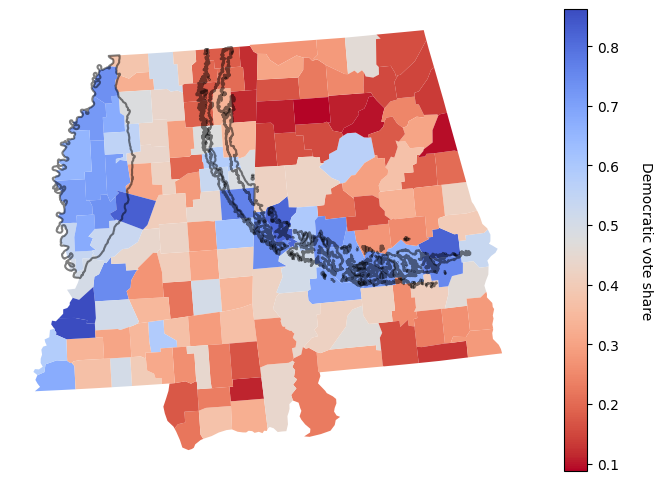

In [34]:

black_belt = gpd.read_file(
    DATA / "processed/black_belt_al_ms_dissolved.geojson"
).to_crs(df.crs)

fig, ax = plt.subplots(figsize=(10,6))

df.plot(
    ax=ax,
    column="dem_share",
    cmap="coolwarm_r",
    legend=True
)

black_belt.boundary.plot(
    ax=ax,
    color="black",
    linewidth=1.5,
    alpha=0.5
)
cbar = next(
    (coll.colorbar for coll in ax.collections if getattr(coll, "colorbar", None) is not None),
    None,
)

if cbar is not None:
    cbar.set_label("Democratic vote share", rotation=270, labelpad=14, va="bottom")
elif len(fig.axes) > 1:
    fig.axes[-1].set_ylabel("Democratic vote share", rotation=270, labelpad=14, va="bottom")

ax.set_axis_off()

map_boundary.boundary.plot(ax=ax, color="black", linewidth=1.5,alpha=0.5, label="Mississippi Alluvial Plain")
ax.set_axis_off()
plt.savefig("../data/processed/dem_vote_share_map_with_map_boundary.png", dpi=300, bbox_inches="tight")

In [35]:
import pandas as pd

In [36]:
al_url = "https://api.census.gov/data/2020/dec/dhc?get=NAME,P3_001N,P3_003N&for=county:*&in=state:01"
ms_url = "https://api.census.gov/data/2020/dec/dhc?get=NAME,P3_001N,P3_003N&for=county:*&in=state:28"

In [37]:
al_pop = pd.read_json(al_url)
ms_pop = pd.read_json(ms_url)

al_pop.columns = al_pop.iloc[0]
al_pop = al_pop.iloc[1:].copy()

ms_pop.columns = ms_pop.iloc[0]
ms_pop = ms_pop.iloc[1:].copy()

pop = pd.concat([al_pop, ms_pop], ignore_index=True)
pop.head()

,NAME,P3_001N,P3_003N,state,county
0,"Limestone County, Alabama",103570,13307,01,083
1,"Lauderdale County, Alabama",93564,9243,01,077
2,"Lawrence County, Alabama",33073,3304,01,079
3,"Lee County, Alabama",174241,39570,01,081
4,"Lowndes County, Alabama",10311,7192,01,085


In [38]:
pop["P3_001N"] = pop["P3_001N"].astype(int)   # total population
pop["P3_003N"] = pop["P3_003N"].astype(int)   # Black alone population

pop["GEOID"] = pop["state"].astype(str).str.zfill(2) + pop["county"].astype(str).str.zfill(3)
pop["pct_black"] = 100 * pop["P3_003N"] / pop["P3_001N"]

pop = pop.rename(columns={
    "NAME": "county_name_census",
    "P3_001N": "total_pop_2020",
    "P3_003N": "black_pop_2020",
})

pop[["GEOID", "county_name_census", "total_pop_2020", "black_pop_2020", "pct_black"]].head()

,GEOID,county_name_census,total_pop_2020,black_pop_2020,pct_black
0,01083,"Limestone County, Alabama",103570,13307,12.848315
1,01077,"Lauderdale County, Alabama",93564,9243,9.878800
2,01079,"Lawrence County, Alabama",33073,3304,9.990022
3,01081,"Lee County, Alabama",174241,39570,22.709925
4,01085,"Lowndes County, Alabama",10311,7192,69.750752


In [39]:
features = features.merge(
    pop[["GEOID", "total_pop_2020", "black_pop_2020", "pct_black"]],
    on="GEOID",
    how="left"
)

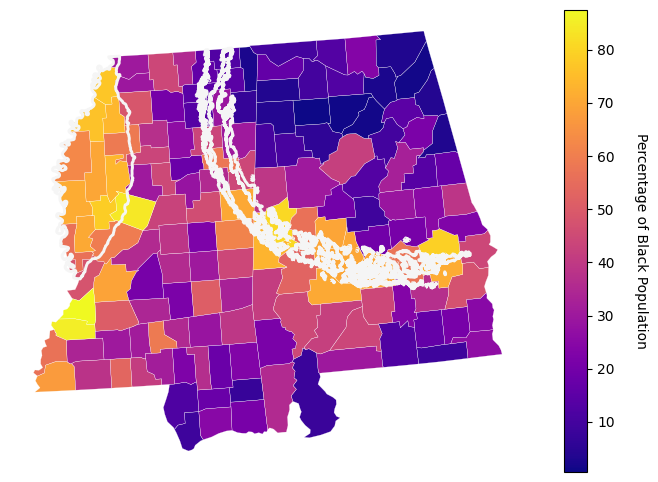

In [40]:
fig, ax = plt.subplots(figsize=(10, 6))

features.plot(
    ax=ax,
    column="pct_black",
    cmap="plasma",
    legend=True,
    edgecolor="none",
)

features.boundary.plot(ax=ax, color="white", linewidth=0.15)
black_belt.boundary.plot(ax=ax, color="whitesmoke", linewidth=2.1)
map_boundary.boundary.plot(ax=ax, color="whitesmoke", linewidth=2.1)

ax.set_axis_off()
cbar = next(
    (coll.colorbar for coll in ax.collections if getattr(coll, "colorbar", None) is not None),
    None,
)

if cbar is not None:
    cbar.set_label("Percentage of Black Population", rotation=270, labelpad=14, va="bottom")
elif len(fig.axes) > 1:
    fig.axes[-1].set_ylabel("Percentage of Black Population", rotation=270, labelpad=14, va="bottom")
plt.savefig("../data/processed/black_population_map.png", dpi=300, bbox_inches="tight")

In [41]:
import geopandas as gpd
import matplotlib.pyplot as plt
from pathlib import Path

In [42]:
DATA = Path("../data")

BLACK_BELT = DATA / "processed/black_belt_al_ms_dissolved.geojson"
PALEOMAP_CS_DIR = DATA / "raw/geology/paleomap/CS"

In [43]:
COMMON_CRS = "EPSG:5070"

black_belt = gpd.read_file(BLACK_BELT).to_crs(COMMON_CRS)

In [44]:
def load_coastline(year):
    path = PALEOMAP_CS_DIR / f"{year}Ma_CS_v7.shp"

    gdf = gpd.read_file(path)

    coastline = gdf.copy()
    coastline["geometry"] = coastline.geometry.boundary

    return coastline.to_crs(COMMON_CRS)

In [45]:
years = [105, 95, 90]

In [46]:
coastlines = {year: load_coastline(year) for year in years}

In [47]:
from shapely.geometry import box
import geopandas as gpd

def clip_to_lonlat_box(
    gdf: gpd.GeoDataFrame,
    xmin: float,
    ymin: float,
    xmax: float,
    ymax: float,
) -> gpd.GeoDataFrame:
    if gdf.crs is None:
        raise ValueError("GeoDataFrame has no CRS.")
    if gdf.crs.to_string() != "EPSG:4326":
        gdf = gdf.to_crs("EPSG:4326")

    bbox = gpd.GeoDataFrame(
        geometry=[box(xmin, ymin, xmax, ymax)],
        crs="EPSG:4326",
    )
    return gdf.clip(bbox)

In [48]:
SE_BBOX = {
    "xmin": -100.0,
    "ymin": 24.0,
    "xmax": -74.0,
    "ymax": 38.5,
}

In [49]:
COMMON_CRS = "EPSG:5070"

def load_coastline_clipped(year):
    path = PALEOMAP_CS_DIR / f"{year}Ma_CS_v7.shp"
    gdf = gpd.read_file(path)

    # Convert polygons to boundary lines
    coast = gdf.copy()
    coast["geometry"] = coast.geometry.boundary
    coast = coast[coast.geometry.notna() & ~coast.geometry.is_empty].copy()

    # Clip in lon/lat BEFORE projecting
    coast = clip_to_lonlat_box(coast, **SE_BBOX)

    # Then project
    coast = coast.to_crs(COMMON_CRS)
    return coast

In [50]:
years = [120,105, 95, 90,85,80,70]
coastlines = {year: load_coastline_clipped(year) for year in years}

/tmp/ipykernel_19482/1287371430.py:21: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  coastlines[year].plot(
/tmp/ipykernel_19482/1287371430.py:37: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()


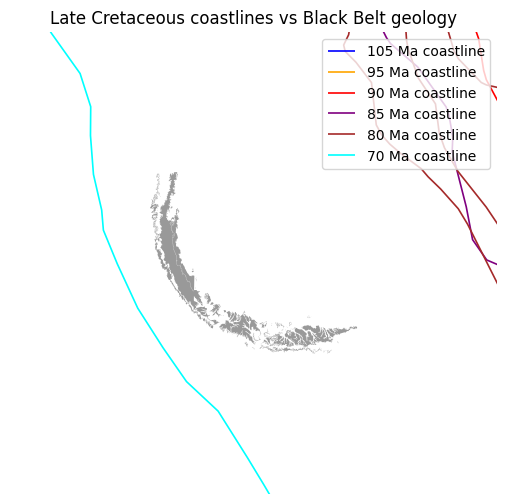

In [51]:
fig, ax = plt.subplots(figsize=(10, 6))

black_belt.plot(
    ax=ax,
    color="black",
    alpha=0.4,
    label="Black Belt geology"
)

colors = {
    105: "blue",
    120: "green",
    95: "orange",
    90: "red",
    85: "purple",
    80: "brown",
    70: "cyan",
}

for year in years:
    coastlines[year].plot(
        ax=ax,
        color=colors[year],
        linewidth=1.2,
        label=f"{year} Ma coastline"
    )

# Force extent to Black Belt region
xmin, ymin, xmax, ymax = black_belt.total_bounds
pad = 250_000  # meters

ax.set_xlim(xmin - pad, xmax + pad)
ax.set_ylim(ymin - pad, ymax + pad)

ax.set_title("Late Cretaceous coastlines vs Black Belt geology")
ax.set_axis_off()
ax.legend()

plt.show()

In [52]:
import geopandas as gpd
import matplotlib.pyplot as plt
from pathlib import Path
from shapely.geometry import box

In [53]:
DATA = Path("../data")

BLACK_BELT = DATA / "processed/black_belt_al_ms_dissolved.geojson"
COUNTIES = DATA / "raw/census/cb_2018_us_county_20m.shp"
PALEOMAP_CS_DIR = DATA / "raw/geology/paleomap/CS"

In [54]:
COMMON_CRS = "EPSG:5070"

years = [120, 105, 95, 90, 85, 80, 70,65,60,50,45,40,35,0]

colors = {
    120: "green",
    105: "blue",
    95: "orange",
    90: "red",
    85: "purple",
    80: "brown",
    70: "cyan",
    65: "pink",
    60: "yellow",
    50: "lightblue",
    45: "lightgreen",
    40: "lightgrey",
    35: "darkgreen",
    0: "black",
}

In [55]:
def clip_to_lonlat_box(
    gdf: gpd.GeoDataFrame,
    xmin: float,
    ymin: float,
    xmax: float,
    ymax: float,
) -> gpd.GeoDataFrame:
    if gdf.crs is None:
        raise ValueError("GeoDataFrame has no CRS.")
    if gdf.crs.to_string() != "EPSG:4326":
        gdf = gdf.to_crs("EPSG:4326")

    bbox = gpd.GeoDataFrame(
        geometry=[box(xmin, ymin, xmax, ymax)],
        crs="EPSG:4326",
    )
    return gdf.clip(bbox)


def polygon_boundaries_as_lines(polygons: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
    lines = polygons.copy()
    lines["geometry"] = lines.geometry.boundary
    lines = lines[lines.geometry.notna() & ~lines.geometry.is_empty].copy()
    return lines


def explode_and_filter_lines(coast_lines: gpd.GeoDataFrame, min_length_km: float = 80.0) -> gpd.GeoDataFrame:
    lines = coast_lines.explode(index_parts=False).copy()
    lines = lines[lines.geometry.notna() & ~lines.geometry.is_empty].copy()
    lines["length_km"] = lines.geometry.length / 1000.0
    return lines[lines["length_km"] >= min_length_km].copy()


def load_coastline_clipped(year, bbox, min_length_km=80):
    path = PALEOMAP_CS_DIR / f"{year}Ma_CS_v7.shp"
    gdf = gpd.read_file(path)
    coast = polygon_boundaries_as_lines(gdf)
    coast = clip_to_lonlat_box(coast, **bbox)
    coast = coast.to_crs(COMMON_CRS)
    coast = explode_and_filter_lines(coast, min_length_km=min_length_km)
    return coast

In [56]:
SE_BBOX = {
    "xmin": -102.0,
    "ymin": 24.0,
    "xmax": -72.0,
    "ymax": 40.0,
}
USA_BBOX = {
    "xmin": -130.0,
    "ymin": 22.0,
    "xmax": -65.0,
    "ymax": 52.0,
}
BLACK_BELT_BBOX = {
    "xmin": -93.5,
    "ymin": 30.0,
    "xmax": -83.0,
    "ymax": 35.5,
}

In [57]:
black_belt = gpd.read_file(BLACK_BELT).to_crs(COMMON_CRS)

counties = gpd.read_file(COUNTIES)
counties = counties[counties["STATEFP"].isin({"01", "28", "13", "22"})].copy()  # AL, MS, GA, LA
counties_se = clip_to_lonlat_box(counties, **SE_BBOX).to_crs(COMMON_CRS)
counties_local = clip_to_lonlat_box(counties, **BLACK_BELT_BBOX).to_crs(COMMON_CRS)

In [58]:
coastlines_se = {
    year: load_coastline_clipped(year, USA_BBOX, min_length_km=150)
    for year in years
}

counties_usa = clip_to_lonlat_box(counties, **USA_BBOX).to_crs(COMMON_CRS)

coastlines_local = {
    year: load_coastline_clipped(year, BLACK_BELT_BBOX, min_length_km=40)
    for year in years
}

In [59]:
modern_usa_outline = gpd.GeoDataFrame(
    geometry=[counties_usa.union_all().boundary],
    crs=COMMON_CRS,
)

modern_local_outline = gpd.GeoDataFrame(
    geometry=[counties_local.union_all().boundary],
    crs=COMMON_CRS,
)

In [60]:
import geopandas as gpd
from pathlib import Path

COMMON_CRS = "EPSG:5070"
COUNTIES = Path("../data/raw/census/cb_2018_us_county_20m.shp")

USA_BBOX = {
    "xmin": -125.0,
    "ymin": 24.0,
    "xmax": -66.0,
    "ymax": 50.0,
}

# Reload raw counties fresh
counties_all = gpd.read_file(COUNTIES)

# Clip to USA bbox in lon/lat, then project
counties_usa = clip_to_lonlat_box(counties_all, **USA_BBOX).to_crs(COMMON_CRS)

# Clean modern USA outline
modern_usa_outline = gpd.GeoDataFrame(
    geometry=[counties_usa.union_all()],
    crs=COMMON_CRS,
)

In [61]:
coastlines_usa = {
    year: load_coastline_clipped(year, USA_BBOX, min_length_km=150)
    for year in years
}

/tmp/ipykernel_19482/398894703.py:17: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  coastlines_local[year].plot(
/tmp/ipykernel_19482/398894703.py:17: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  coastlines_local[year].plot(
/tmp/ipykernel_19482/398894703.py:17: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  coastlines_local[year].plot(
/tmp/ipykernel_19482/398894703.py:17: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  coastlines_local[year].plot(


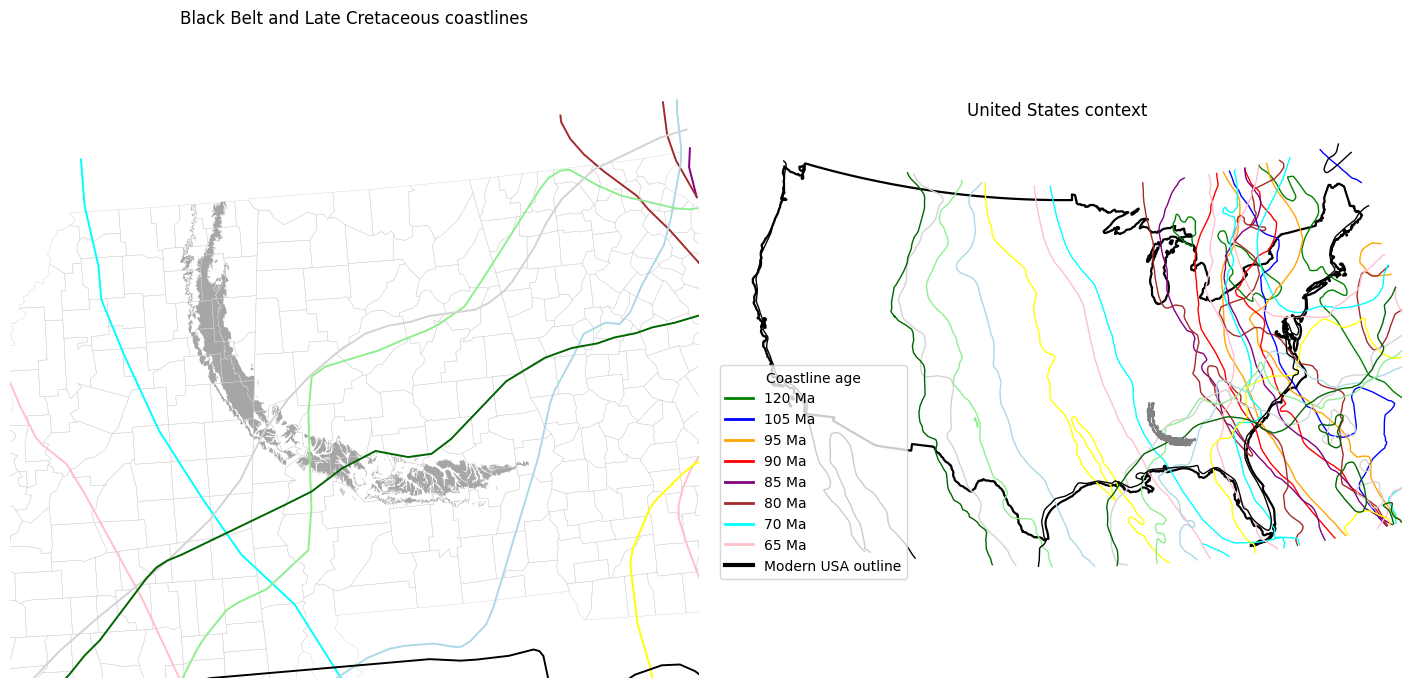

In [62]:
fig, axes = plt.subplots(1, 2, figsize=(14, 7), constrained_layout=True)

# -------------------------
# Left panel: zoom on Black Belt
# -------------------------
ax = axes[0]

counties_local.boundary.plot(ax=ax, color="lightgrey", linewidth=0.3)

black_belt.plot(
    ax=ax,
    color="black",
    alpha=0.35
)

for year in years:
    coastlines_local[year].plot(
        ax=ax,
        color=colors[year],
        linewidth=1.4,
    )

xmin, ymin, xmax, ymax = black_belt.total_bounds
pad = 180_000

ax.set_xlim(xmin - pad, xmax + pad)
ax.set_ylim(ymin - pad, ymax + pad)

ax.set_title("Black Belt and Late Cretaceous coastlines")
ax.set_axis_off()

# -------------------------
# Right panel: USA context
# -------------------------
ax = axes[1]

modern_usa_outline.boundary.plot(
    ax=ax,
    color=colors[0],
    linewidth=1.6
)

for year in years:
    coastlines_usa[year].plot(
        ax=ax,
        color=colors[year],
        linewidth=1.0,
    )

black_belt.boundary.plot(
    ax=ax,
    color="grey",
    linewidth=1.2,
    linestyle="--"
)

xmin, ymin, xmax, ymax = counties_usa.total_bounds
pad = 300_000
ax.set_xlim(xmin - pad, xmax + pad)
ax.set_ylim(ymin - pad, ymax + pad)

ax.set_title("United States context")
ax.set_axis_off()

plt.legend(
    handles=[
        plt.Line2D([0], [0], color=colors[120], lw=2, label="120 Ma"),
        plt.Line2D([0], [0], color=colors[105], lw=2, label="105 Ma"),
        plt.Line2D([0], [0], color=colors[95], lw=2, label="95 Ma"),
        plt.Line2D([0], [0], color=colors[90], lw=2, label="90 Ma"),
        plt.Line2D([0], [0], color=colors[85], lw=2, label="85 Ma"),
        plt.Line2D([0], [0], color=colors[80], lw=2, label="80 Ma"),
        plt.Line2D([0], [0], color=colors[70], lw=2, label="70 Ma"),
        plt.Line2D([0], [0], color=colors[65], lw=2, label="65 Ma"),
        plt.Line2D([0], [0], color=colors[0], lw=3, label="Modern USA outline"),
    ],
    loc="lower left",
    title="Coastline age"
)

plt.show()